# Lab 5 DL:
Chọn 1 cơ sở dữ liệu liên quan đến image captioning (chọn dataset nhỏ nhỏ), có thể search trên hugging face/kaggle.
- Nhóm CNN: resnet, vgg, alexnet
- Nhóm RNN: lstm, mamba
- Lựa chọn 1 model trong nhóm CNN và 1 model trong nhóm RNN để thực thi quá trình huấn luyện theo multi-model để giải quyết bài toán image captioning

1. người 1: multi-model không sử dụng framework
2. người 2: có thể dùng 1 trong 2 framework clip/align

In [ ]:
!pip -q install datasets transformers nltk

In [ ]:
import os
import re
import io
import sys
import random
from typing import List, Dict, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as T
import torchvision.models as models

from PIL import Image
import matplotlib.pyplot as plt
import requests
from collections import Counter
from datasets import load_dataset, load_from_disk

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 42
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CFG = {
    "dataset_name": "jxie/flickr8k",
    "min_freq": 3,
    "embed_size": 256,
    "hidden_size": 512,
    "num_layers": 1,
    "dropout": 0.1,
    "batch_size": 32,
    "num_workers": 2,
    "lr": 1e-3,
    "epochs": 10,
    "max_len": 30,
    "max_samples": {"train": 2000, "validation": 500, "test": 500},
    "fine_tune_cnn": False,
}

IMAGE_SIZE = 224
print(f"Device: {DEVICE}")

Device: cuda


# Multi-model ResNet50 + LSTM, không dùng framework

Phần này tự thiết kế pipeline image captioning bằng PyTorch:

- Tiền xử lý dữ liệu Flickr8k từ Hugging Face.
- Xây dựng từ điển caption.
- Dùng ResNet50 pretrained làm CNN encoder để trích xuất đặc trưng ảnh.
- Dùng LSTM làm decoder để sinh caption theo từng token.
- Huấn luyện bằng cross entropy loss.
- Đánh giá bằng BLEU-1 và BLEU-4 trên tập test nhỏ.


# Vocabulary

In [ ]:
def simple_tokenize(text: str) -> List[str]:
    """Tach tu don gian cho caption tieng Anh."""
    text = text.lower().strip()
    return re.findall(r"[a-z0-9]+", text)


class Vocabulary:
    """Quan ly tu dien cho bai toan image captioning."""

    def __init__(self, min_freq: int = 2):
        self.min_freq = min_freq
        self.pad_token = "<pad>"
        self.start_token = "<start>"
        self.end_token = "<end>"
        self.unk_token = "<unk>"
        self.word2idx: Dict[str, int] = {}
        self.idx2word: Dict[int, str] = {}
        self._init_special_tokens()

    def _init_special_tokens(self):
        for token in [self.pad_token, self.start_token, self.end_token, self.unk_token]:
            self._add_word(token)
        self.pad_idx = self.word2idx[self.pad_token]
        self.start_idx = self.word2idx[self.start_token]
        self.end_idx = self.word2idx[self.end_token]
        self.unk_idx = self.word2idx[self.unk_token]

    def _add_word(self, word: str):
        if word not in self.word2idx:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def __len__(self) -> int:
        return len(self.word2idx)

    def build(self, captions: List[str]):
        """Xay dung vocab tu danh sach caption."""
        counter = Counter()
        for caption in captions:
            counter.update(simple_tokenize(caption))
        for word, freq in counter.items():
            if freq >= self.min_freq:
                self._add_word(word)

    def encode(self, caption: str, max_len: Optional[int] = None) -> List[int]:
        """Ma hoa caption thanh danh sach id, co them <end> o cuoi."""
        tokens = simple_tokenize(caption)
        if max_len is not None:
            tokens = tokens[: max_len - 1]
        ids = [self.word2idx.get(tok, self.unk_idx) for tok in tokens]
        ids.append(self.end_idx)
        return ids

    def decode(self, ids: List[int], stop_at_end: bool = True) -> str:
        """Giai ma danh sach id thanh caption."""
        words = []
        for idx in ids:
            if idx == self.end_idx and stop_at_end:
                break
            if idx in (self.pad_idx, self.start_idx):
                continue
            words.append(self.idx2word.get(idx, self.unk_token))
        return " ".join(words)


def build_vocab_from_captions(captions: List[str], min_freq: int = 2) -> Vocabulary:
    """Ham tien loi de tao vocab tu tap caption."""
    vocab = Vocabulary(min_freq=min_freq)
    vocab.build(captions)
    return vocab

# Flickr8k

In [ ]:
def _normalize_caption_value(value) -> Optional[str]:
    if isinstance(value, str):
        text = value.strip()
        return text if text else None
    if isinstance(value, dict):
        for key in ["text", "caption", "sentence"]:
            if key in value and value[key]:
                return str(value[key]).strip()
    return None


def _extract_captions(example: Dict) -> List[str]:
    candidate_keys = ["captions", "caption", "sentence", "sentences", "text", "annotations"]
    for key in candidate_keys:
        if key not in example:
            continue
        caps = example[key]
        if isinstance(caps, str):
            return [caps.strip()] if caps.strip() else []
        if isinstance(caps, dict):
            if "text" in caps and isinstance(caps["text"], list):
                values = [str(c).strip() for c in caps["text"] if str(c).strip()]
                if values:
                    return values
            norm = _normalize_caption_value(caps)
            return [norm] if norm else []
        if isinstance(caps, list):
            results = []
            for item in caps:
                norm = _normalize_caption_value(item)
                if norm:
                    results.append(norm)
            if results:
                return results

    caption_keys = [k for k in example.keys() if str(k).startswith("caption_")]
    if caption_keys:
        def _caption_key_order(key: str) -> int:
            parts = key.split("_")
            return int(parts[-1]) if parts[-1].isdigit() else 0
        results = []
        for key in sorted(caption_keys, key=_caption_key_order):
            norm = _normalize_caption_value(example.get(key))
            if norm:
                results.append(norm)
        if results:
            return results
    return []


def _extract_image(example: Dict):
    for key in ["image", "img", "image_path", "filepath", "file_name", "file_path"]:
        if key in example:
            img = example[key]
            if isinstance(img, dict):
                if "path" in img:
                    return img["path"]
                if "bytes" in img:
                    return Image.open(io.BytesIO(img["bytes"])).convert("RGB")
            return img
    raise KeyError("Khong tim thay truong anh trong dataset")


def _dataset_to_items(ds_split, max_samples: Optional[int] = None) -> List[Dict]:
    items = []
    for example in ds_split:
        captions = _extract_captions(example)
        if not captions:
            continue
        try:
            image = _extract_image(example)
        except KeyError:
            continue
        items.append({"image": image, "captions": captions})
        if max_samples is not None and len(items) >= max_samples:
            break
    return items


def preview_image_any(image_obj):
    """Dua anh trong dataset ve PIL RGB de xem mau."""
    if isinstance(image_obj, Image.Image):
        return image_obj.convert("RGB")
    if isinstance(image_obj, str):
        return Image.open(image_obj).convert("RGB")
    if isinstance(image_obj, dict):
        if "path" in image_obj:
            return Image.open(image_obj["path"]).convert("RGB")
        if "bytes" in image_obj:
            return Image.open(io.BytesIO(image_obj["bytes"])).convert("RGB")
    if hasattr(image_obj, "convert"):
        return image_obj.convert("RGB")
    raise ValueError("Dinh dang anh khong duoc ho tro de xem mau.")


def show_data_samples(items: List[Dict], n: int = 4, seed: int = 42, title: str = "Mau du lieu"):
    """Hien thi vai anh trong dataset kem caption de kiem tra nhanh du lieu."""
    if not items:
        print("Khong co du lieu de hien thi mau.")
        return

    n = min(max(int(n), 1), len(items))
    rng = random.Random(seed)
    sample_items = rng.sample(items, k=n) if len(items) > n else list(items)
    cols = min(n, 4)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.5 * rows))
    axes = np.array(axes).reshape(-1)
    fig.suptitle(title, fontsize=14)

    for ax, item in zip(axes, sample_items):
        image = preview_image_any(item["image"])
        caption = item["captions"][0] if item.get("captions") else "Khong co caption"
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(f"Caption: {caption}", fontsize=9, wrap=True)

    for ax in axes[len(sample_items):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def download_and_prepare_data_hf(
    dataset_name: str = "jxie/flickr8k",
    max_samples: Optional[Dict[str, int]] = None,
    seed: int = 42,
    dataset_obj=None,
) -> Dict[str, List[Dict]]:
    """Tai va chuan bi du lieu Flickr8k tu Hugging Face.

    Tra ve dict gom cac split: train, validation, test.
    """
    ds = None
    last_err = None

    if dataset_obj is not None:
        ds = dataset_obj
    else:
        if isinstance(dataset_name, str) and os.path.exists(dataset_name):
            try:
                ds = load_from_disk(dataset_name)
            except Exception as exc:
                last_err = exc
        if ds is None:
            candidates = [dataset_name] if isinstance(dataset_name, str) else list(dataset_name)
            for name in candidates:
                try:
                    ds = load_dataset(name)
                    break
                except Exception as exc:
                    last_err = exc

    if ds is None:
        raise RuntimeError(f"Khong the tai dataset. Loi: {last_err}")

    if all(k in ds for k in ["train", "validation", "test"]):
        split_map = {"train": ds["train"], "validation": ds["validation"], "test": ds["test"]}
    elif all(k in ds for k in ["train", "val", "test"]):
        split_map = {"train": ds["train"], "validation": ds["val"], "test": ds["test"]}
    else:
        key = "train" if "train" in ds else list(ds.keys())[0]
        full = ds[key].shuffle(seed=seed)
        n_total = len(full)
        n_train = int(0.8 * n_total)
        n_val = int(0.1 * n_total)
        split_map = {
            "train": full.select(range(0, n_train)),
            "validation": full.select(range(n_train, n_train + n_val)),
            "test": full.select(range(n_train + n_val, n_total)),
        }

    items = {}
    for split_name, split_ds in split_map.items():
        limit = None
        if isinstance(max_samples, dict):
            limit = max_samples.get(split_name)
        elif isinstance(max_samples, int):
            limit = max_samples
        items[split_name] = _dataset_to_items(split_ds, max_samples=limit)

    if not items.get("train"):
        sample = split_map["train"][0] if "train" in split_map and len(split_map["train"]) > 0 else {}
        raise ValueError(f"Tap train rong sau khi xu ly. Keys: {list(sample.keys())}")
    return items

# Dataset & DataLoader

In [ ]:
def build_transform(image_size: int = 224) -> T.Compose:
    """Tao transform chuan hoa phu hop ResNet."""
    return T.Compose(
        [
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )


class Flickr8kCaptionDataset(Dataset):
    """Dataset cho Flickr8k gom anh va caption."""

    def __init__(
        self,
        items: List[Dict],
        vocab: Vocabulary,
        transform: Optional[T.Compose] = None,
        max_len: Optional[int] = None,
        training: bool = True,
    ):
        self.items = items
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len
        self.training = training

    def __len__(self) -> int:
        return len(self.items)

    def _load_image(self, image_obj):
        if isinstance(image_obj, Image.Image):
            return image_obj.convert("RGB")
        if isinstance(image_obj, str):
            return Image.open(image_obj).convert("RGB")
        if isinstance(image_obj, dict) and "path" in image_obj:
            return Image.open(image_obj["path"]).convert("RGB")
        if hasattr(image_obj, "convert"):
            return image_obj.convert("RGB")
        raise ValueError("Dinh dang anh khong ho tro.")

    def __getitem__(self, idx: int):
        item = self.items[idx]
        image = self._load_image(item["image"])
        if self.transform is not None:
            image = self.transform(image)
        captions = item["captions"]
        caption = random.choice(captions) if self.training else captions[0]
        caption_ids = self.vocab.encode(caption, max_len=self.max_len)
        return image, torch.tensor(caption_ids, dtype=torch.long)


def caption_collate_fn(batch, pad_idx: int):
    """Pad caption trong batch ve cung do dai."""
    images, captions = zip(*batch)
    images = torch.stack(images, dim=0)
    captions = pad_sequence(captions, batch_first=True, padding_value=pad_idx)
    return images, captions


def create_dataloaders(
    train_items: List[Dict],
    val_items: List[Dict],
    test_items: List[Dict],
    vocab: Vocabulary,
    transform: T.Compose,
    batch_size: int = 32,
    num_workers: int = 2,
    max_len: int = 30,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """Tao DataLoader cho train/val/test."""
    train_ds = Flickr8kCaptionDataset(train_items, vocab, transform, max_len=max_len, training=True)
    val_ds = Flickr8kCaptionDataset(val_items, vocab, transform, max_len=max_len, training=False)
    test_ds = Flickr8kCaptionDataset(test_items, vocab, transform, max_len=max_len, training=False)

    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        collate_fn=lambda b: caption_collate_fn(b, vocab.pad_idx),
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        collate_fn=lambda b: caption_collate_fn(b, vocab.pad_idx),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        collate_fn=lambda b: caption_collate_fn(b, vocab.pad_idx),
    )
    return train_loader, val_loader, test_loader

# Model (CNN Encoder + LSTM Decoder)

## CNN Encoder

In [ ]:
def _get_resnet50():
    """Lay ResNet50 pretrained voi tuong thich nhieu phien ban torchvision."""
    try:
        weights = models.ResNet50_Weights.DEFAULT
        return models.resnet50(weights=weights)
    except AttributeError:
        return models.resnet50(pretrained=True)


class EncoderCNN(nn.Module):
    """CNN Encoder dua tren ResNet50."""

    def __init__(self, embed_size: int, fine_tune_cnn: bool = False):
        super().__init__()
        resnet = _get_resnet50()
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])
        self.linear = nn.Linear(resnet.fc.in_features, embed_size)
        self.bn = nn.BatchNorm1d(embed_size, momentum=0.01)
        self.fine_tune(fine_tune_cnn)

    def fine_tune(self, enable: bool = False):
        for param in self.cnn.parameters():
            param.requires_grad = enable

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        if any(p.requires_grad for p in self.cnn.parameters()):
            features = self.cnn(images)
        else:
            with torch.no_grad():
                features = self.cnn(images)
        features = features.view(features.size(0), -1)
        features = self.linear(features)
        features = self.bn(features)
        return features

## LSTM Decoder

In [ ]:
class DecoderRNN(nn.Module):
    """RNN Decoder su dung LSTM de sinh caption."""

    def __init__(
        self,
        embed_size: int,
        hidden_size: int,
        vocab_size: int,
        num_layers: int = 1,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(
            embed_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, features: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        embeddings = self.embed(captions[:, :-1])
        inputs = torch.cat((features.unsqueeze(1), embeddings), dim=1)
        hiddens, _ = self.lstm(inputs)
        outputs = self.fc(hiddens)
        return outputs

    def sample(self, features: torch.Tensor, max_len: int = 20, end_idx: Optional[int] = None) -> List[int]:
        """Sinh caption bang giai thuat greedy."""
        sampled_ids: List[int] = []
        inputs = features.unsqueeze(1)
        states = None
        for _ in range(max_len):
            hiddens, states = self.lstm(inputs, states)
            outputs = self.fc(hiddens.squeeze(1))
            predicted = outputs.argmax(1)
            predicted_id = predicted.item()
            sampled_ids.append(predicted_id)
            if end_idx is not None and predicted_id == end_idx:
                break
            inputs = self.embed(predicted).unsqueeze(1)
        return sampled_ids

# Train/Validate loop

In [ ]:
def train_one_epoch(
    encoder: EncoderCNN,
    decoder: DecoderRNN,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    grad_clip: Optional[float] = None,
) -> float:
    """Train 1 epoch va tra ve loss trung binh."""
    encoder.train()
    decoder.train()
    total_loss = 0.0

    for images, captions in dataloader:
        images = images.to(device)
        captions = captions.to(device)

        features = encoder(images)
        outputs = decoder(features, captions)
        loss = criterion(outputs.reshape(-1, decoder.vocab_size), captions.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        if grad_clip is not None:
            nn.utils.clip_grad_norm_(decoder.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(dataloader.dataset)


def validate_one_epoch(
    encoder: EncoderCNN,
    decoder: DecoderRNN,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    """Danh gia 1 epoch va tra ve loss trung binh."""
    encoder.eval()
    decoder.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, captions in dataloader:
            images = images.to(device)
            captions = captions.to(device)

            features = encoder(images)
            outputs = decoder(features, captions)
            loss = criterion(outputs.reshape(-1, decoder.vocab_size), captions.reshape(-1))
            total_loss += loss.item() * images.size(0)

    return total_loss / len(dataloader.dataset)


def train_model(
    encoder: EncoderCNN,
    decoder: DecoderRNN,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int = 3,
    grad_clip: Optional[float] = None,
) -> Dict[str, List[float]]:
    """Train nhieu epoch va tra ve lich su loss."""
    history = {"train_loss": [], "val_loss": []}
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(
            encoder, decoder, train_loader, criterion, optimizer, device, grad_clip=grad_clip
        )
        val_loss = validate_one_epoch(encoder, decoder, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch}/{epochs} - train: {train_loss:.4f} - val: {val_loss:.4f}")
    return history

# Google Drive cache

In [ ]:
def _is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False


def get_dataset_from_drive_or_hf(dataset_name: str, drive_cache_dir: str):
    """Doc dataset tu Drive neu co; neu khong thi tai tu HF va luu."""
    if os.path.exists(drive_cache_dir):
        print(f"Load dataset tu Drive: {drive_cache_dir}")
        return load_from_disk(drive_cache_dir)

    print("Khong tim thay dataset tren Drive, dang tai tu HF...")
    ds = load_dataset(dataset_name)
    os.makedirs(drive_cache_dir, exist_ok=True)
    ds.save_to_disk(drive_cache_dir)
    print(f"Da luu dataset vao Drive: {drive_cache_dir}")
    return ds


DATASET_OBJ = None
if _is_colab():
    from google.colab import drive

    drive.mount("/content/drive")
    os.environ["HF_HOME"] = "/content/hf_cache"
    DRIVE_DATA_DIR = "/content/drive/MyDrive/hf_datasets/flickr8k"
    DATASET_OBJ = get_dataset_from_drive_or_hf(CFG["dataset_name"], DRIVE_DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Load dataset tu Drive: /content/drive/MyDrive/hf_datasets/flickr8k


# Load data & DataLoaders

In [ ]:
split_items = download_and_prepare_data_hf(
    dataset_name=CFG["dataset_name"],
    max_samples=CFG["max_samples"],
    seed=SEED,
    dataset_obj=DATASET_OBJ,
 )
train_items = split_items["train"]
val_items = split_items["validation"]
test_items = split_items["test"]

print(f"Train/Val/Test: {len(train_items)} / {len(val_items)} / {len(test_items)}")

DATA_SAMPLE_COUNT = 4
show_data_samples(train_items, n=DATA_SAMPLE_COUNT, seed=SEED, title="Mau du lieu train")

all_train_captions = [cap for item in train_items for cap in item["captions"]]
vocab = build_vocab_from_captions(all_train_captions, min_freq=CFG["min_freq"])
print(f"Vocab size: {len(vocab)}")

transform = build_transform(IMAGE_SIZE)
train_loader, val_loader, test_loader = create_dataloaders(
    train_items,
    val_items,
    test_items,
    vocab,
    transform,
    batch_size=CFG["batch_size"],
    num_workers=CFG["num_workers"],
    max_len=CFG["max_len"],
)

TEST_ITEMS = test_items

# Train model

In [ ]:
encoder = EncoderCNN(embed_size=CFG["embed_size"], fine_tune_cnn=CFG["fine_tune_cnn"])
decoder = DecoderRNN(
    embed_size=CFG["embed_size"],
    hidden_size=CFG["hidden_size"],
    vocab_size=len(vocab),
    num_layers=CFG["num_layers"],
    dropout=CFG["dropout"],
)

encoder.to(DEVICE)
decoder.to(DEVICE)

params = list(decoder.parameters()) + list(encoder.linear.parameters()) + list(encoder.bn.parameters())
if CFG["fine_tune_cnn"]:
    params += list(encoder.cnn.parameters())

optimizer = torch.optim.Adam(params, lr=CFG["lr"])
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

history = train_model(
    encoder,
    decoder,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    DEVICE,
    epochs=CFG["epochs"],
    grad_clip=5.0,
)

MODEL = {"encoder": encoder, "decoder": decoder}

Epoch 1/10 - train: 5.3956 - val: 4.3929
Epoch 2/10 - train: 4.1844 - val: 3.7571
Epoch 3/10 - train: 3.8057 - val: 3.5427
Epoch 4/10 - train: 3.5962 - val: 3.3934
Epoch 5/10 - train: 3.4183 - val: 3.2826
Epoch 6/10 - train: 3.3078 - val: 3.2324
Epoch 7/10 - train: 3.1852 - val: 3.1603
Epoch 8/10 - train: 3.0965 - val: 3.1167
Epoch 9/10 - train: 2.9913 - val: 3.0700
Epoch 10/10 - train: 2.9316 - val: 3.0464


# Đánh giá mô hình ResNet50 + LSTM

BLEU được dùng để so sánh caption sinh ra với các caption tham chiếu của ảnh. BLEU-1 phản ánh mức khớp từ đơn, còn BLEU-4 khắt khe hơn vì xét cụm 4 từ.


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


def load_pil_image_any(image_obj):
    """Đưa nhiều kiểu dữ liệu ảnh về PIL RGB."""
    if isinstance(image_obj, Image.Image):
        return image_obj.convert("RGB")
    if isinstance(image_obj, str):
        return Image.open(image_obj).convert("RGB")
    if isinstance(image_obj, dict):
        if "path" in image_obj:
            return Image.open(image_obj["path"]).convert("RGB")
        if "bytes" in image_obj:
            return Image.open(io.BytesIO(image_obj["bytes"])).convert("RGB")
    if hasattr(image_obj, "convert"):
        return image_obj.convert("RGB")
    raise ValueError("Định dạng ảnh không được hỗ trợ.")


@torch.no_grad()
def generate_lstm_caption(image_obj, encoder, decoder, vocab: Vocabulary, transform, device, max_len: int = 20) -> str:
    """Sinh caption cho một ảnh bằng mô hình ResNet50 + LSTM."""
    image = load_pil_image_any(image_obj)
    image_tensor = transform(image).unsqueeze(0).to(device)
    encoder.eval()
    decoder.eval()
    features = encoder(image_tensor)
    sampled_ids = decoder.sample(features, max_len=max_len, end_idx=vocab.end_idx)
    return vocab.decode(sampled_ids, stop_at_end=True)


def evaluate_lstm_bleu(test_items, encoder, decoder, vocab, transform, device, max_eval: int = 100):
    """Tính BLEU-1 và BLEU-4 cho mô hình ResNet50 + LSTM."""
    smoothing = SmoothingFunction().method1
    bleu1_scores = []
    bleu4_scores = []

    for item in test_items[:max_eval]:
        pred_caption = generate_lstm_caption(
            item["image"], encoder, decoder, vocab, transform, device, max_len=CFG["max_len"]
        )
        references = [simple_tokenize(cap) for cap in item["captions"]]
        hypothesis = simple_tokenize(pred_caption)
        if not hypothesis:
            hypothesis = [vocab.unk_token]

        bleu1_scores.append(
            sentence_bleu(
                references,
                hypothesis,
                weights=(1.0, 0.0, 0.0, 0.0),
                smoothing_function=smoothing,
            )
        )
        bleu4_scores.append(
            sentence_bleu(
                references,
                hypothesis,
                weights=(0.25, 0.25, 0.25, 0.25),
                smoothing_function=smoothing,
            )
        )

    return {
        "BLEU-1": float(np.mean(bleu1_scores)) if bleu1_scores else 0.0,
        "BLEU-4": float(np.mean(bleu4_scores)) if bleu4_scores else 0.0,
        "num_eval": len(bleu1_scores),
    }


lstm_bleu = evaluate_lstm_bleu(
    test_items,
    encoder,
    decoder,
    vocab,
    transform,
    DEVICE,
    max_eval=min(100, len(test_items)),
)
print("Kết quả ResNet50 + LSTM:", lstm_bleu)


Kết quả ResNet50 + LSTM: {'BLEU-1': 0.48628056325384117, 'BLEU-4': 0.09336698020163814, 'num_eval': 100}


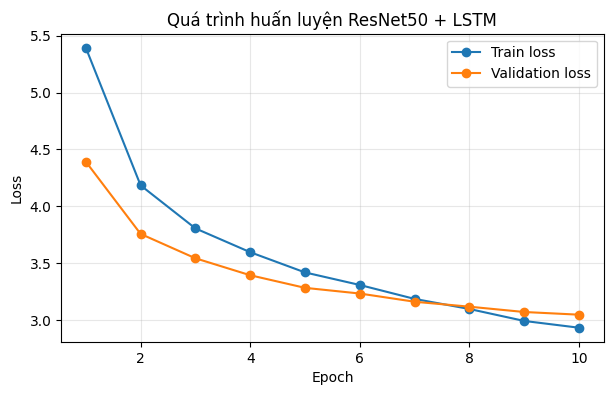

In [ ]:
def plot_training_history(history):
    """Vẽ đường train loss và validation loss."""
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], marker="o", label="Train loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Quá trình huấn luyện ResNet50 + LSTM")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_training_history(history)


# Demo (Inference)

In [ ]:
def normalize_caption_for_match(text: str) -> str:
    """Chuan hoa caption de so khop du doan voi ground truth."""
    return " ".join(simple_tokenize(text))


def caption_matches_ground_truth(pred_caption: str, ground_truths: List[str]) -> bool:
    pred_norm = normalize_caption_for_match(pred_caption)
    gt_norms = [normalize_caption_for_match(gt) for gt in ground_truths]
    return bool(pred_norm) and pred_norm in gt_norms


def load_demo_image(image_obj):
    if isinstance(image_obj, str) and image_obj.startswith("http"):
        resp = requests.get(image_obj, timeout=10)
        resp.raise_for_status()
        return Image.open(io.BytesIO(resp.content)).convert("RGB")
    return load_pil_image_any(image_obj)


def select_demo_items(image_path, num_demos: int = 1, ground_truth: Optional[List[str]] = None):
    """Chon anh demo tu TEST_ITEMS hoac tu duong dan nguoi dung dua vao."""
    num_demos = max(int(num_demos), 1)
    if image_path is None or str(image_path).lower() in ["random", "rand"]:
        if "TEST_ITEMS" not in globals() or not TEST_ITEMS:
            raise ValueError("Khong co du lieu test de chon ngau nhien.")
        k = min(num_demos, len(TEST_ITEMS))
        return random.sample(TEST_ITEMS, k=k) if len(TEST_ITEMS) > k else list(TEST_ITEMS)

    if isinstance(image_path, (list, tuple)):
        return [{"image": path, "captions": ground_truth or []} for path in image_path[:num_demos]]
    return [{"image": image_path, "captions": ground_truth or []}]


def inference_and_show_demo(
    image_path,
    model,
    vocab: Vocabulary,
    transform,
    max_len: int = 20,
    num_demos: int = 1,
    ground_truth: Optional[List[str]] = None,
):
    """Du doan caption va hien thi nhieu anh demo kem ground truth."""
    if isinstance(model, dict):
        encoder = model["encoder"]
        decoder = model["decoder"]
    elif isinstance(model, (tuple, list)):
        encoder, decoder = model
    else:
        encoder = model.encoder
        decoder = model.decoder

    device = next(encoder.parameters()).device
    demo_items = select_demo_items(image_path, num_demos=num_demos, ground_truth=ground_truth)
    results = []

    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        for item in demo_items:
            image = load_demo_image(item["image"])
            image_tensor = transform(image).unsqueeze(0).to(device)
            features = encoder(image_tensor)
            sampled_ids = decoder.sample(features, max_len=max_len, end_idx=vocab.end_idx)
            pred_caption = vocab.decode(sampled_ids, stop_at_end=True)
            ground_truths = item.get("captions", [])
            is_correct = caption_matches_ground_truth(pred_caption, ground_truths) if ground_truths else False
            results.append(
                {
                    "image": image,
                    "pred_caption": pred_caption,
                    "ground_truths": ground_truths,
                    "is_correct": is_correct,
                }
            )

    cols = min(len(results), 3)
    rows = int(np.ceil(len(results) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5.4 * rows))
    axes = np.array(axes).reshape(-1)

    for idx, (ax, result) in enumerate(zip(axes, results), start=1):
        pred_caption = result["pred_caption"] or "Caption rong"
        ground_truths = result["ground_truths"]
        gt_text = ground_truths[0] if ground_truths else "Khong co ground truth"
        color = "green" if result["is_correct"] else "red"
        status = "DUNG" if result["is_correct"] else "SAI"

        ax.imshow(result["image"])
        ax.axis("off")
        ax.set_title(
            f"{idx}. {status}\nPred: {pred_caption}\nGT: {gt_text}",
            color=color,
            fontsize=9,
            wrap=True,
        )
        print(f"Demo {idx}: {status}")
        print(f"  Du doan: {pred_caption}")
        print(f"  Ground truth: {' | '.join(ground_truths) if ground_truths else 'Khong co'}")

    for ax in axes[len(results):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    return results


DEMO_COUNT = 4
_ = inference_and_show_demo(
    image_path=None,
    model=MODEL,
    vocab=vocab,
    transform=transform,
    max_len=CFG["max_len"],
    num_demos=DEMO_COUNT,
)

# Image captioning dùng CLIP

CLIP không phải là mô hình sinh văn bản từng token như LSTM. Vì vậy, trong notebook này CLIP được dùng theo hướng retrieval-based captioning:

- Mỗi ảnh và mỗi caption được mã hóa vào cùng một không gian embedding.
- CLIP được fine-tune nhẹ trên các cặp ảnh - caption của tập train.
- Khi suy luận, ảnh test được so khớp với ngân hàng caption ứng viên.
- Caption có độ tương đồng cao nhất được chọn làm caption dự đoán.

Cách này phù hợp với yêu cầu vì có dùng framework/model multimodal CLIP.


In [ ]:
from transformers import CLIPModel, CLIPProcessor

CLIP_CFG = {
    "model_name": "openai/clip-vit-base-patch32",
    "batch_size": 16,
    "lr": 1e-5,
    "epochs": 10,
    "train_pairs": 512,
    "val_pairs": 128,
    "candidate_pool_size": 800,
    "max_eval": 100,
}

print("Mô hình CLIP:", CLIP_CFG["model_name"])


Mô hình CLIP: openai/clip-vit-base-patch32


In [ ]:
class CLIPCaptionPairDataset(Dataset):
    """Dataset cặp ảnh - caption cho fine-tuning CLIP."""

    def __init__(self, items: List[Dict], max_pairs: Optional[int] = None, seed: int = 42):
        pairs = []
        for item in items:
            for caption in item["captions"]:
                pairs.append((item["image"], caption))

        rng = random.Random(seed)
        rng.shuffle(pairs)
        if max_pairs is not None:
            pairs = pairs[:max_pairs]
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_obj, caption = self.pairs[idx]
        image = load_pil_image_any(image_obj)
        return image, caption


def make_clip_collate_fn(processor: CLIPProcessor):
    """Tạo hàm collate để CLIPProcessor xử lý cả ảnh và caption."""

    def _collate(batch):
        images, captions = zip(*batch)
        return processor(
            text=list(captions),
            images=list(images),
            return_tensors="pt",
            padding=True,
            truncation=True,
        )

    return _collate


def move_clip_batch_to_device(batch, device):
    return {key: value.to(device) for key, value in batch.items()}


In [ ]:
def train_clip_one_epoch(clip_model, dataloader, optimizer, device):
    """Fine-tune CLIP trong một epoch bằng contrastive loss có sẵn của CLIP."""
    clip_model.train()
    total_loss = 0.0

    for batch in dataloader:
        batch = move_clip_batch_to_device(batch, device)
        outputs = clip_model(**batch, return_loss=True)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = batch["pixel_values"].size(0)
        total_loss += loss.item() * batch_size

    return total_loss / len(dataloader.dataset)


@torch.no_grad()
def validate_clip_loss(clip_model, dataloader, device):
    """Tính loss validation cho CLIP."""
    clip_model.eval()
    total_loss = 0.0

    for batch in dataloader:
        batch = move_clip_batch_to_device(batch, device)
        outputs = clip_model(**batch, return_loss=True)
        loss = outputs.loss
        batch_size = batch["pixel_values"].size(0)
        total_loss += loss.item() * batch_size

    return total_loss / len(dataloader.dataset)


def train_clip_model(clip_model, train_loader, val_loader, optimizer, device, epochs: int = 1):
    """Huấn luyện CLIP và lưu lịch sử loss."""
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        train_loss = train_clip_one_epoch(clip_model, train_loader, optimizer, device)
        val_loss = validate_clip_loss(clip_model, val_loader, device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"CLIP Epoch {epoch}/{epochs} - train: {train_loss:.4f} - val: {val_loss:.4f}")

    return history


In [ ]:
clip_processor = CLIPProcessor.from_pretrained(CLIP_CFG["model_name"])
clip_model = CLIPModel.from_pretrained(CLIP_CFG["model_name"]).to(DEVICE)

clip_train_ds = CLIPCaptionPairDataset(
    train_items,
    max_pairs=CLIP_CFG["train_pairs"],
    seed=SEED,
)
clip_val_ds = CLIPCaptionPairDataset(
    val_items,
    max_pairs=CLIP_CFG["val_pairs"],
    seed=SEED,
)

clip_collate_fn = make_clip_collate_fn(clip_processor)
clip_train_loader = DataLoader(
    clip_train_ds,
    batch_size=CLIP_CFG["batch_size"],
    shuffle=True,
    num_workers=0,
    collate_fn=clip_collate_fn,
)
clip_val_loader = DataLoader(
    clip_val_ds,
    batch_size=CLIP_CFG["batch_size"],
    shuffle=False,
    num_workers=0,
    collate_fn=clip_collate_fn,
)

clip_optimizer = torch.optim.AdamW(clip_model.parameters(), lr=CLIP_CFG["lr"])
clip_history = train_clip_model(
    clip_model,
    clip_train_loader,
    clip_val_loader,
    clip_optimizer,
    DEVICE,
    epochs=CLIP_CFG["epochs"],
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP Epoch 1/10 - train: 0.1768 - val: 0.2703
CLIP Epoch 2/10 - train: 0.0978 - val: 0.2540
CLIP Epoch 3/10 - train: 0.0750 - val: 0.2704
CLIP Epoch 4/10 - train: 0.0650 - val: 0.3234
CLIP Epoch 5/10 - train: 0.0553 - val: 0.3758
CLIP Epoch 6/10 - train: 0.0440 - val: 0.3374
CLIP Epoch 7/10 - train: 0.0634 - val: 0.4342
CLIP Epoch 8/10 - train: 0.0401 - val: 0.3686
CLIP Epoch 9/10 - train: 0.0169 - val: 0.3662
CLIP Epoch 10/10 - train: 0.0200 - val: 0.3692


In [ ]:
def build_clip_caption_bank(items, max_candidates: Optional[int] = None):
    """Tạo ngân hàng caption ứng viên từ tập train."""
    caption_bank = []
    seen = set()

    for item in items:
        for caption in item["captions"]:
            normalized = caption.strip()
            if normalized and normalized not in seen:
                caption_bank.append(normalized)
                seen.add(normalized)
            if max_candidates is not None and len(caption_bank) >= max_candidates:
                return caption_bank

    return caption_bank


def _to_clip_tensor(features):
    """Chuyển output của CLIP về Tensor để tương thích nhiều phiên bản transformers."""
    if isinstance(features, torch.Tensor):
        return features
    for attr in ["text_embeds", "image_embeds", "pooler_output", "last_hidden_state"]:
        value = getattr(features, attr, None)
        if isinstance(value, torch.Tensor):
            if attr == "last_hidden_state":
                return value[:, 0, :]
            return value
    if isinstance(features, (tuple, list)):
        for value in features:
            if isinstance(value, torch.Tensor):
                return value
    raise TypeError(f"Không chuyển được output CLIP kiểu {type(features)} về Tensor.")


def _normalize_clip_features(features):
    """Chuẩn hóa embedding CLIP theo L2 norm."""
    features = _to_clip_tensor(features)
    return features / features.norm(dim=-1, keepdim=True).clamp_min(1e-12)


def _get_clip_text_features(clip_model, inputs):
    """Lấy text embedding đã qua projection, tương thích nhiều phiên bản transformers."""
    features = clip_model.get_text_features(**inputs)
    if isinstance(features, torch.Tensor):
        return features
    if hasattr(clip_model, "text_model") and hasattr(clip_model, "text_projection"):
        text_inputs = {key: inputs[key] for key in ["input_ids", "attention_mask", "position_ids"] if key in inputs}
        text_outputs = clip_model.text_model(**text_inputs)
        pooled_output = _to_clip_tensor(text_outputs)
        return clip_model.text_projection(pooled_output)
    return _to_clip_tensor(features)


def _get_clip_image_features(clip_model, inputs):
    """Lấy image embedding đã qua projection, tương thích nhiều phiên bản transformers."""
    features = clip_model.get_image_features(**inputs)
    if isinstance(features, torch.Tensor):
        return features
    if hasattr(clip_model, "vision_model") and hasattr(clip_model, "visual_projection"):
        vision_outputs = clip_model.vision_model(pixel_values=inputs["pixel_values"])
        pooled_output = _to_clip_tensor(vision_outputs)
        return clip_model.visual_projection(pooled_output)
    return _to_clip_tensor(features)


@torch.no_grad()
def encode_clip_texts(texts, clip_model, clip_processor, device, batch_size: int = 32):
    """Mã hóa danh sách caption thành embedding đã chuẩn hóa."""
    clip_model.eval()
    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]
        inputs = clip_processor(
            text=batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
        )
        inputs = {key: value.to(device) for key, value in inputs.items()}
        text_features = _normalize_clip_features(_get_clip_text_features(clip_model, inputs))
        all_embeddings.append(text_features.cpu())

    return torch.cat(all_embeddings, dim=0)


@torch.no_grad()
def encode_clip_image(image_obj, clip_model, clip_processor, device):
    """Mã hóa một ảnh thành embedding đã chuẩn hóa."""
    image = load_pil_image_any(image_obj)
    inputs = clip_processor(images=image, return_tensors="pt")
    inputs = {key: value.to(device) for key, value in inputs.items()}
    image_features = _normalize_clip_features(_get_clip_image_features(clip_model, inputs))
    return image_features.cpu(), image


def retrieve_clip_captions(image_obj, clip_model, clip_processor, caption_bank, text_embeddings, device, top_k: int = 5):
    """Lấy top-k caption gần ảnh nhất theo cosine similarity trong không gian CLIP."""
    image_embedding, image = encode_clip_image(image_obj, clip_model, clip_processor, device)
    similarities = (image_embedding @ text_embeddings.T).squeeze(0)
    top_k = min(top_k, len(caption_bank))
    scores, indices = torch.topk(similarities, k=top_k)

    results = []
    for score, idx in zip(scores.tolist(), indices.tolist()):
        results.append({"caption": caption_bank[idx], "score": float(score)})
    return results, image


def evaluate_clip_retrieval_bleu(test_items, clip_model, clip_processor, caption_bank, text_embeddings, device, max_eval: int = 100):
    """Đánh giá retrieval-based captioning của CLIP bằng BLEU."""
    smoothing = SmoothingFunction().method1
    bleu1_scores = []
    bleu4_scores = []

    for item in test_items[:max_eval]:
        top_results, _ = retrieve_clip_captions(
            item["image"],
            clip_model,
            clip_processor,
            caption_bank,
            text_embeddings,
            device,
            top_k=1,
        )
        pred_caption = top_results[0]["caption"]
        references = [simple_tokenize(cap) for cap in item["captions"]]
        hypothesis = simple_tokenize(pred_caption)
        if not hypothesis:
            hypothesis = ["<unk>"]

        bleu1_scores.append(
            sentence_bleu(
                references,
                hypothesis,
                weights=(1.0, 0.0, 0.0, 0.0),
                smoothing_function=smoothing,
            )
        )
        bleu4_scores.append(
            sentence_bleu(
                references,
                hypothesis,
                weights=(0.25, 0.25, 0.25, 0.25),
                smoothing_function=smoothing,
            )
        )

    return {
        "BLEU-1": float(np.mean(bleu1_scores)) if bleu1_scores else 0.0,
        "BLEU-4": float(np.mean(bleu4_scores)) if bleu4_scores else 0.0,
        "num_eval": len(bleu1_scores),
    }


clip_caption_bank = build_clip_caption_bank(
    train_items,
    max_candidates=CLIP_CFG["candidate_pool_size"],
)
print("Số caption ứng viên cho CLIP:", len(clip_caption_bank))

clip_text_embeddings = encode_clip_texts(
    clip_caption_bank,
    clip_model,
    clip_processor,
    DEVICE,
    batch_size=32,
)

clip_bleu = evaluate_clip_retrieval_bleu(
    test_items,
    clip_model,
    clip_processor,
    clip_caption_bank,
    clip_text_embeddings,
    DEVICE,
    max_eval=min(CLIP_CFG["max_eval"], len(test_items)),
)
print("Kết quả CLIP retrieval captioning:", clip_bleu)


Số caption ứng viên cho CLIP: 800
Kết quả CLIP retrieval captioning: {'BLEU-1': 0.4608645657093223, 'BLEU-4': 0.10286467449766391, 'num_eval': 100}


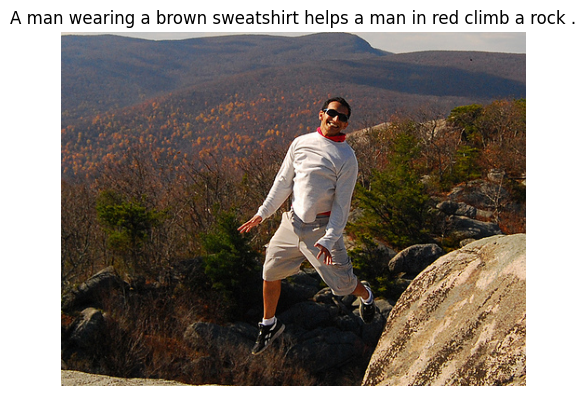

Top caption từ CLIP:
1. A man wearing a brown sweatshirt helps a man in red climb a rock . | score = 0.2592
2. A man climbs steep rocks . | score = 0.2525
3. A man in a red shirt is learning how to climb a cliff . | score = 0.2508
4. A boy climbing a rock face | score = 0.2353
5. A man in a red shirt climbs a rock while another man stands behind to help him . | score = 0.2344


In [ ]:
def clip_inference_and_show_demo(image_path, clip_model, clip_processor, caption_bank, text_embeddings, device, top_k: int = 5):
    """Hiển thị ảnh và các caption CLIP gợi ý."""
    if image_path is None or str(image_path).lower() in ["random", "rand"]:
        if "TEST_ITEMS" not in globals() or not TEST_ITEMS:
            raise ValueError("Không có dữ liệu test để chọn ngẫu nhiên.")
        sample = random.choice(TEST_ITEMS)
        image_obj = sample["image"]
    else:
        image_obj = image_path

    top_results, image = retrieve_clip_captions(
        image_obj,
        clip_model,
        clip_processor,
        caption_bank,
        text_embeddings,
        device,
        top_k=top_k,
    )

    title = top_results[0]["caption"]
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(title)
    plt.show()

    print("Top caption từ CLIP:")
    for rank, result in enumerate(top_results, start=1):
        print(f"{rank}. {result['caption']} | score = {result['score']:.4f}")


clip_inference_and_show_demo(
    image_path=None,
    clip_model=clip_model,
    clip_processor=clip_processor,
    caption_bank=clip_caption_bank,
    text_embeddings=clip_text_embeddings,
    device=DEVICE,
    top_k=5,
)


In [ ]:
def print_final_comparison(lstm_bleu, clip_bleu):
    """In bảng so sánh ngắn gọn giữa hai hướng."""
    rows = [
        ("Multi-model ResNet50 + LSTM", lstm_bleu),
        ("Multi-model CLIP retrieval", clip_bleu),
    ]
    print("So sánh kết quả BLEU")
    print("-" * 72)
    print(f"{'Mô hình':35s} | {'BLEU-1':>10s} | {'BLEU-4':>10s} | {'Số mẫu':>8s}")
    print("-" * 72)
    for name, metrics in rows:
        print(
            f"{name:35s} | "
            f"{metrics['BLEU-1']:10.4f} | "
            f"{metrics['BLEU-4']:10.4f} | "
            f"{metrics['num_eval']:8d}"
        )


print_final_comparison(lstm_bleu, clip_bleu)


So sánh kết quả BLEU
------------------------------------------------------------------------
Mô hình                             |     BLEU-1 |     BLEU-4 |   Số mẫu
------------------------------------------------------------------------
Multi-model ResNet50 + LSTM         |     0.4863 |     0.0934 |      100
Multi-model CLIP retrieval          |     0.4609 |     0.1029 |      100
